In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv('../data/cardekho.csv')
#Explore dataset
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [3]:
#Get information about dataframes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   str    
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   str    
 5   seller_type         8128 non-null   str    
 6   transmission        8128 non-null   str    
 7   owner               8128 non-null   str    
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   str    
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), str(6)
memory usage: 762.1 KB


In [4]:
df.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


In [5]:
#Check missing values
df.isnull().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64

In [6]:
df.dropna(inplace=True)
df.isnull().sum()

name                  0
year                  0
selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
mileage(km/ltr/kg)    0
engine                0
max_power             0
seats                 0
dtype: int64

In [7]:
#drop name column and change categorical data into numerical
df.drop('name', axis=1, inplace=True)
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [8]:
#Use one-hot-encording for map categorical data
df = pd.get_dummies(df, columns=['fuel', 'seller_type', 'transmission'], drop_first=True)
df['owner'].unique()

<StringArray>
[         'First Owner',         'Second Owner',          'Third Owner',
 'Fourth & Above Owner',       'Test Drive Car']
Length: 5, dtype: str

In [9]:
#Use Lable encording
df['owner'] = df['owner'].map({
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 5
})
#Convert string type to float
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')
df.info()

<class 'pandas.DataFrame'>
Index: 7907 entries, 0 to 8127
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   year                          7907 non-null   int64  
 1   selling_price                 7907 non-null   int64  
 2   km_driven                     7907 non-null   int64  
 3   owner                         7907 non-null   int64  
 4   mileage(km/ltr/kg)            7907 non-null   float64
 5   engine                        7907 non-null   float64
 6   max_power                     7906 non-null   float64
 7   seats                         7907 non-null   float64
 8   fuel_Diesel                   7907 non-null   bool   
 9   fuel_LPG                      7907 non-null   bool   
 10  fuel_Petrol                   7907 non-null   bool   
 11  seller_type_Individual        7907 non-null   bool   
 12  seller_type_Trustmark Dealer  7907 non-null   bool   
 13  transmission_Manual

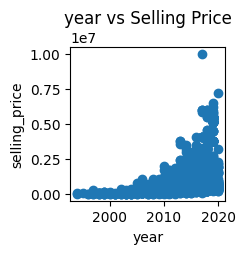

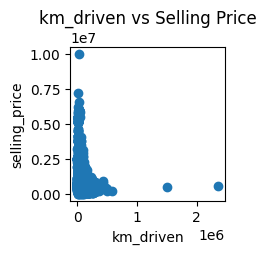

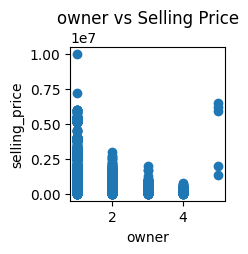

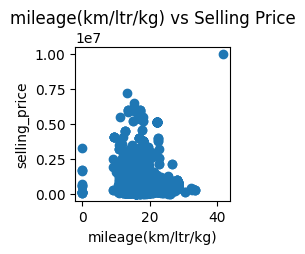

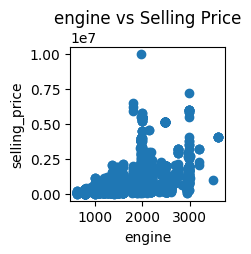

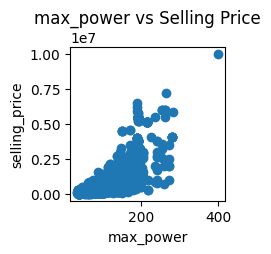

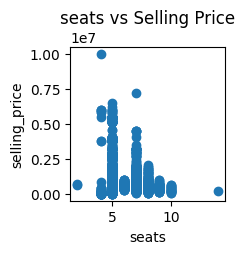

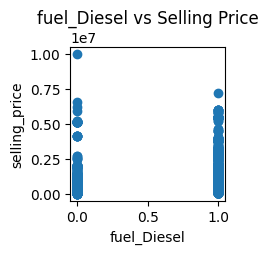

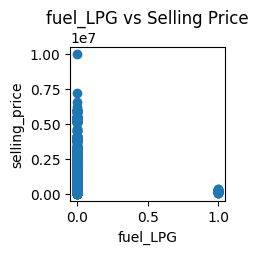

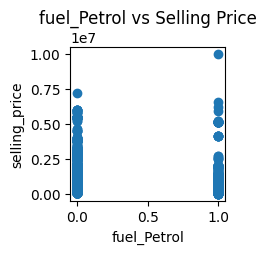

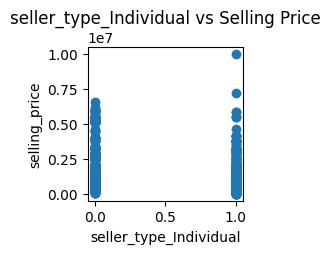

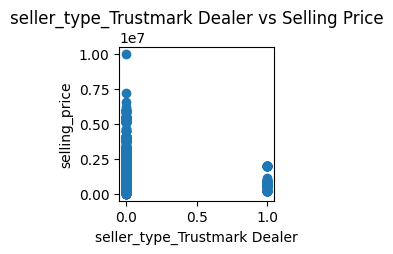

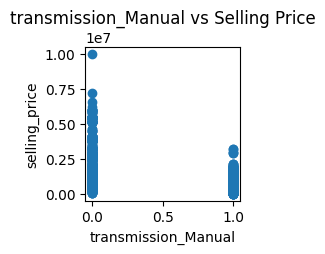

In [10]:
#Data visulization
df.dropna(subset=['max_power'], inplace=True)
X_df = df.drop('selling_price', axis=1)
Y_df = df['selling_price']

for col in X_df.columns:
    plt.figure(figsize=(2,2))
    plt.scatter(df[col], Y_df)
    plt.xlabel(col)
    plt.ylabel('selling_price')
    plt.title(f'{col} vs Selling Price')
    plt.show()

In [11]:
X = X_df.values
Y = Y_df.values

In [12]:
#Split data into train and test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.2, random_state=42)

In [13]:
#Normalize Data
scaler = StandardScaler()
X_trained_scale = scaler.fit_transform(X_train)
X_tested_scale = scaler.transform(X_test)

In [14]:
#Train Model
model = LinearRegression()
model.fit(X_trained_scale, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
model.coef_
model.intercept_

np.float64(659941.4231499087)

In [16]:
#Evaluation

##On Train Data
Y_trained_pred = model.predict(X_trained_scale)
trained_rmse = np.sqrt(mean_squared_error(Y_train, Y_trained_pred))
train_r2 = r2_score(Y_train, Y_trained_pred)
print(f'Train RMSE: {trained_rmse:.2f}, R2: {train_r2:.2f}')

Train RMSE: 458126.37, R2: 0.70


In [23]:
Y_tested_pred = model.predict(X_tested_scale)
tested_rmse = np.sqrt(mean_squared_error(Y_test, Y_tested_pred))
test_r2 = r2_score(Y_test, Y_tested_pred)
print(f'Test RMSE: {tested_rmse:.2f}, R2: {test_r2:.2f}')

Test RMSE: 463772.51, R2: 0.67


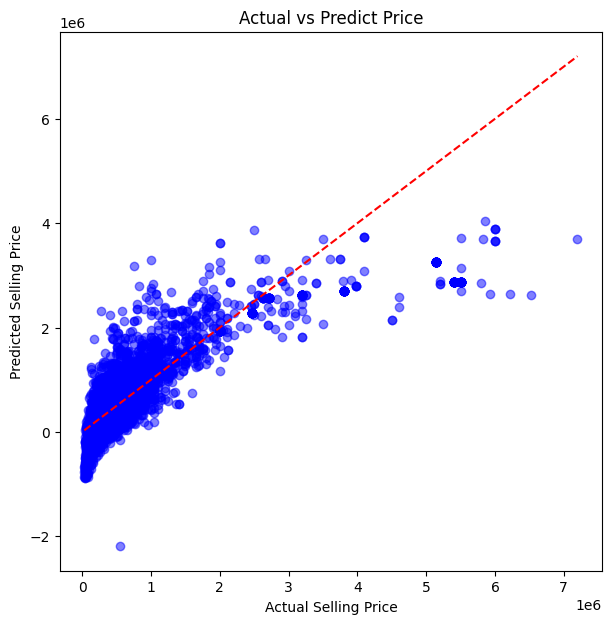

In [20]:
#Scatter plot of Actual Vs Predict

plt.figure(figsize=(7,7))
plt.scatter(Y_test, Y_tested_pred, alpha=0.5, color='blue')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predict Price')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')
plt.show()

In [30]:
#Train Random Forest Classifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [31]:
Y_tested_pred_rf = rf_model.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(Y_test, Y_tested_pred_rf))
r2_score_rf = r2_score(Y_test, Y_tested_pred_rf)
print(f'Test RMSE: {rmse_rf} R2_Score: {r2_score_rf}')

Test RMSE: 253358.70635517614 R2_Score: 0.9016241838534285


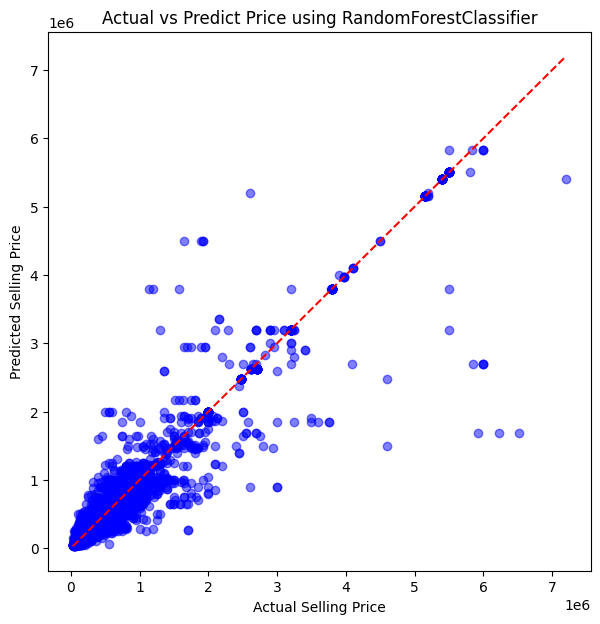

In [32]:
plt.figure(figsize=(7,7))
plt.scatter(Y_test, Y_tested_pred_rf, alpha=0.5, color='blue')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predict Price using RandomForestClassifier')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')
plt.show()